<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="300"/>

CSGE603130 • Kecerdasan Artifisial dan Sains Data Dasar

Semester Gasal 2025/2026

Fakultas Ilmu Komputer, Universitas Indonesia

## **Lab 5: Linear Model**

### **Tenggat Waktu: 9 November 2025, 23.55 WIB**
</center>

#### **Ketentuan:**

1. Dokumen template lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan di SCeLe
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah **pertanyaan** yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dengan format penamaan **Kelas_Lab5_NPM_Nama.ipynb** . Contoh: A_Lab5_1806205773_Abdurrafi Arief.ipynb. Kesalahan dalam pengumpulan nama akan dikenakan pinalti sebesar 5 poin.
4. Kumpulkan dokumen tersebut pada submisi yang telah disediakan di SCeLe sesuai dengan kelas masing-masing sebelum **Tenggat Waktu: 9 November 2025, 23.55 WIB**.
5. Keterlambatan pengumpulan akan dikenakan pinalti sebesar 5 poin per jam (pembulatan ke atas). Dengan cut off 1 hari.
6. Lab ini dirancang sebagai **tugas mandiri**. Plagiarisme tidak diperkenankan dalam bentuk apapun. Adapun kolaborasi berupa diskusi (tanpa menyalin maupun mengambil jawaban orang lain) dan literasi masih diperbolehkan dengan mencantumkan kolaborator dan sumber.
7. Penggunaan GenAI tidak diperbolehkan.
8. Pakta Integritas **Wajib** di isi dan di jalankan. Submisi hanya akan dinilai jika pakta integritas di isi dan di jalankan.
9. Sebelum di kumpulkan, kode **WAJIB** dijalankan. Jika tidak, dikenakan penalti sebesar 50%.
10. Mahasiswa wajib mencantumkan semua sumber yang menjadi referensi jawaban.
11. Kesalahan submisi merupakan tanggung jawab mahasiswa dan akan dikenakan penalti sesuai dengan ketentuan yang berlaku. Asisten dosen tidak menerima submisi di luar Scele.

## **Pernyataan Integritas**

In [52]:
# Isi dengan data diri Anda
NAMA = "Jeremi Felix Adiyatma"
KELAS = "Kasdad A"
NPM = "2306219575"
USERNAME_KAGGLE = "felixsimbolon"

# Isi dengan NPM teman yang berdiskusi dengan Anda
KOLABORATOR = []

# Isi dengan sumber referensi yang Anda gunakan dalam mengerjakan
REFERENSI = []

In [53]:
PERNYATAAN_INTEGRITAS = "Saya, %s dari kelas %s dengan NPM %s, menyatakan bahwa seluruh jawaban pada pekerjaan ini murni saya kerjakan sendiri.\n\
Saya tidak mencontek jawaban, memberikan jawaban, maupun menyalin dari sumber manapun.\n \
\n\
Jika saya melanggar pernyataan tersebut, saya siap menerima konsekuensi apapun yang diberikan.\n   \
(%s)" % (NAMA, KELAS, NPM, NAMA)

print(PERNYATAAN_INTEGRITAS)

Saya, Jeremi Felix Adiyatma dari kelas Kasdad A dengan NPM 2306219575, menyatakan bahwa seluruh jawaban pada pekerjaan ini murni saya kerjakan sendiri.
Saya tidak mencontek jawaban, memberikan jawaban, maupun menyalin dari sumber manapun.
 
Jika saya melanggar pernyataan tersebut, saya siap menerima konsekuensi apapun yang diberikan.
   (Jeremi Felix Adiyatma)


In [54]:
!pip install --upgrade --no-cache-dir gdown
!pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
# Load spotifyreccomendation.csv
!gdown --id '1YzDCruQOvR2ADYokG4oRtPFrio9Z1_Kv'

# Load flag.csv
!gdown --id '1o8g4O27Pxi2PMZXG6okNMzx57e8sOPbA'

# Load cancer_reg.csv
!gdown --id '1lGCck9f6YtCvTdnr3I-7QvnKckzMPhxt'

C:\Users\W-book\AppData\Roaming\Python\Python313\site-packages\gdown\__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id='1YzDCruQOvR2ADYokG4oRtPFrio9Z1_Kv'

but Gdown can't. Please check connections and permissions.
C:\Users\W-book\AppData\Roaming\Python\Python313\site-packages\gdown\__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You ma

## Intro to Linear Models for Regression and Classification

Pada lab kali ini, Anda akan mengimplementasikan model-model linear untuk melakukan prediksi regresi maupun klasifikasi. Beberapa model tersebut antara lain:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Logistic Regression
- Softmax Regression

Sebelum ke latihan soal, kita akan melakukan persiapan data dan melihat secara ringkas teori dari masing-masing jenis regresi. Setelah itu, kita akan melakukan implementasi menggunakan library Scikit learn.

**NOTE:** Penjelasan yang diberikan pada setiap jenis regresi, sebagian besar, hanya untuk menunjukkan saja. Anda perlu belajar dari sumber lain (contoh: slide kuliah) untuk lebih memahami materi-materi di sini. Walau demikian, semoga penjelasan di sini dapat membantu Anda :)

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression

from yellowbrick.regressor import ResidualsPlot
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, precision_score, recall_score, accuracy_score

## Penjelasan Dataset

Deskripsi dataset cancer_reg:
Dataset berisi data survey sensus di Amerika. Berikut merupakan deskripsi dari setiap atribut
pada dataset:

* TARGET_deathRate: Dependent variable. Mean per capita (100,000) cancer
mortalities(a)
* avgAnnCount: Mean number of reported cases of cancer diagnosed annually(a)
* avgDeathsPerYear: Mean number of reported mortalities due to cancer(a)
* incidenceRate: Mean per capita (100,000) cancer diagoses(a)
* medianIncome: Median income per county (b)
* popEst2015: Population of county (b)
* povertyPercent: Percent of populace in poverty (b)
* studyPerCap: Per capita number of cancer-related clinical trials per county (a)
* binnedInc: Median income per capita binned by decile (b)
* MedianAge: Median age of county residents (b)
* MedianAgeMale: Median age of male county residents (b)
* MedianAgeFemale: Median age of female county residents (b)
* Geography: County name (b)
* AvgHouseholdSize: Mean household size of county (b)
* PercentMarried: Percent of county residents who are married (b)
* PctNoHS18_24: Percent of county residents ages 18-24 highest education attained:
less than high school (b)
* PctHS18_24: Percent of county residents ages 18-24 highest education attained: high
school diploma (b)
* PctSomeCol18_24: Percent of county residents ages 18-24 highest education
attained: some college (b)
* PctBachDeg18_24: Percent of county residents ages 18-24 highest education
attained: bachelor's degree (b)
PctHS25_Over: Percent of county residents ages 25 and over highest education
attained: high school diploma (b)
* PctBachDeg25_Over: Percent of county residents ages 25 and over highest
education attained: bachelor's degree (b)
* PctEmployed16_Over: Percent of county residents ages 16 and over employed (b)
* PctUnemployed16_Over: Percent of county residents ages 16 and over unemployed
(b)
* PctPrivateCoverage: Percent of county residents with private health coverage (b)
* PctPrivateCoverageAlone: Percent of county residents with private health coverage
alone (no public assistance) (b)
* PctEmpPrivCoverage: Percent of county residents with employee-provided private
health coverage (b)
* PctPublicCoverage: Percent of county residents with government-provided health
coverage (b)
* PctPubliceCoverageAlone: Percent of county residents with government-provided
health coverage alone (b)
* PctWhite: Percent of county residents who identify as White (b)
* PctBlack: Percent of county residents who identify as Black (b)
* PctAsian: Percent of county residents who identify as Asian (b)
* PctOtherRace: Percent of county residents who identify in a category which is not
White, Black, or Asian (b)
* PctMarriedHouseholds: Percent of married households (b)
* BirthRate: Number of live births relative to number of women in county (b)

In [57]:
df = pd.read_csv('cancer_reg.csv', encoding='ISO-8859-1')
df.head()

,avgAnnCount,avgDeathsPerYear,TARGET_deathRate,incidenceRate,medIncome,popEst2015,povertyPercent,studyPerCap,binnedInc,MedianAge,...,PctPrivateCoverageAlone,PctEmpPrivCoverage,PctPublicCoverage,PctPublicCoverageAlone,PctWhite,PctBlack,PctAsian,PctOtherRace,PctMarriedHouseholds,BirthRate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


In [58]:
df.columns

Index(['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate',
       'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'binnedInc',
       'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'Geography',
       'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24',
       'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over',
       'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over',
       'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage',
       'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack',
       'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate'],
      dtype='object')

In [59]:
df.dtypes

avgAnnCount                float64
avgDeathsPerYear             int64
TARGET_deathRate           float64
incidenceRate              float64
medIncome                    int64
popEst2015                   int64
povertyPercent             float64
studyPerCap                float64
binnedInc                   object
MedianAge                  float64
MedianAgeMale              float64
MedianAgeFemale            float64
Geography                   object
AvgHouseholdSize           float64
PercentMarried             float64
PctNoHS18_24               float64
PctHS18_24                 float64
PctSomeCol18_24            float64
PctBachDeg18_24            float64
PctHS25_Over               float64
PctBachDeg25_Over          float64
PctEmployed16_Over         float64
PctUnemployed16_Over       float64
PctPrivateCoverage         float64
PctPrivateCoverageAlone    float64
PctEmpPrivCoverage         float64
PctPublicCoverage          float64
PctPublicCoverageAlone     float64
PctWhite            

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear         3047 non-null   int64  
 2   TARGET_deathRate         3047 non-null   float64
 3   incidenceRate            3047 non-null   float64
 4   medIncome                3047 non-null   int64  
 5   popEst2015               3047 non-null   int64  
 6   povertyPercent           3047 non-null   float64
 7   studyPerCap              3047 non-null   float64
 8   binnedInc                3047 non-null   object 
 9   MedianAge                3047 non-null   float64
 10  MedianAgeMale            3047 non-null   float64
 11  MedianAgeFemale          3047 non-null   float64
 12  Geography                3047 non-null   object 
 13  AvgHouseholdSize         3047 non-null   float64
 14  PercentMarried          

In [86]:
df.describe(include="object")

,binnedInc,Geography
count,3047,3047
unique,10,3047
top,"(45201, 48021.6]","Geary County, Kansas"
freq,306,1


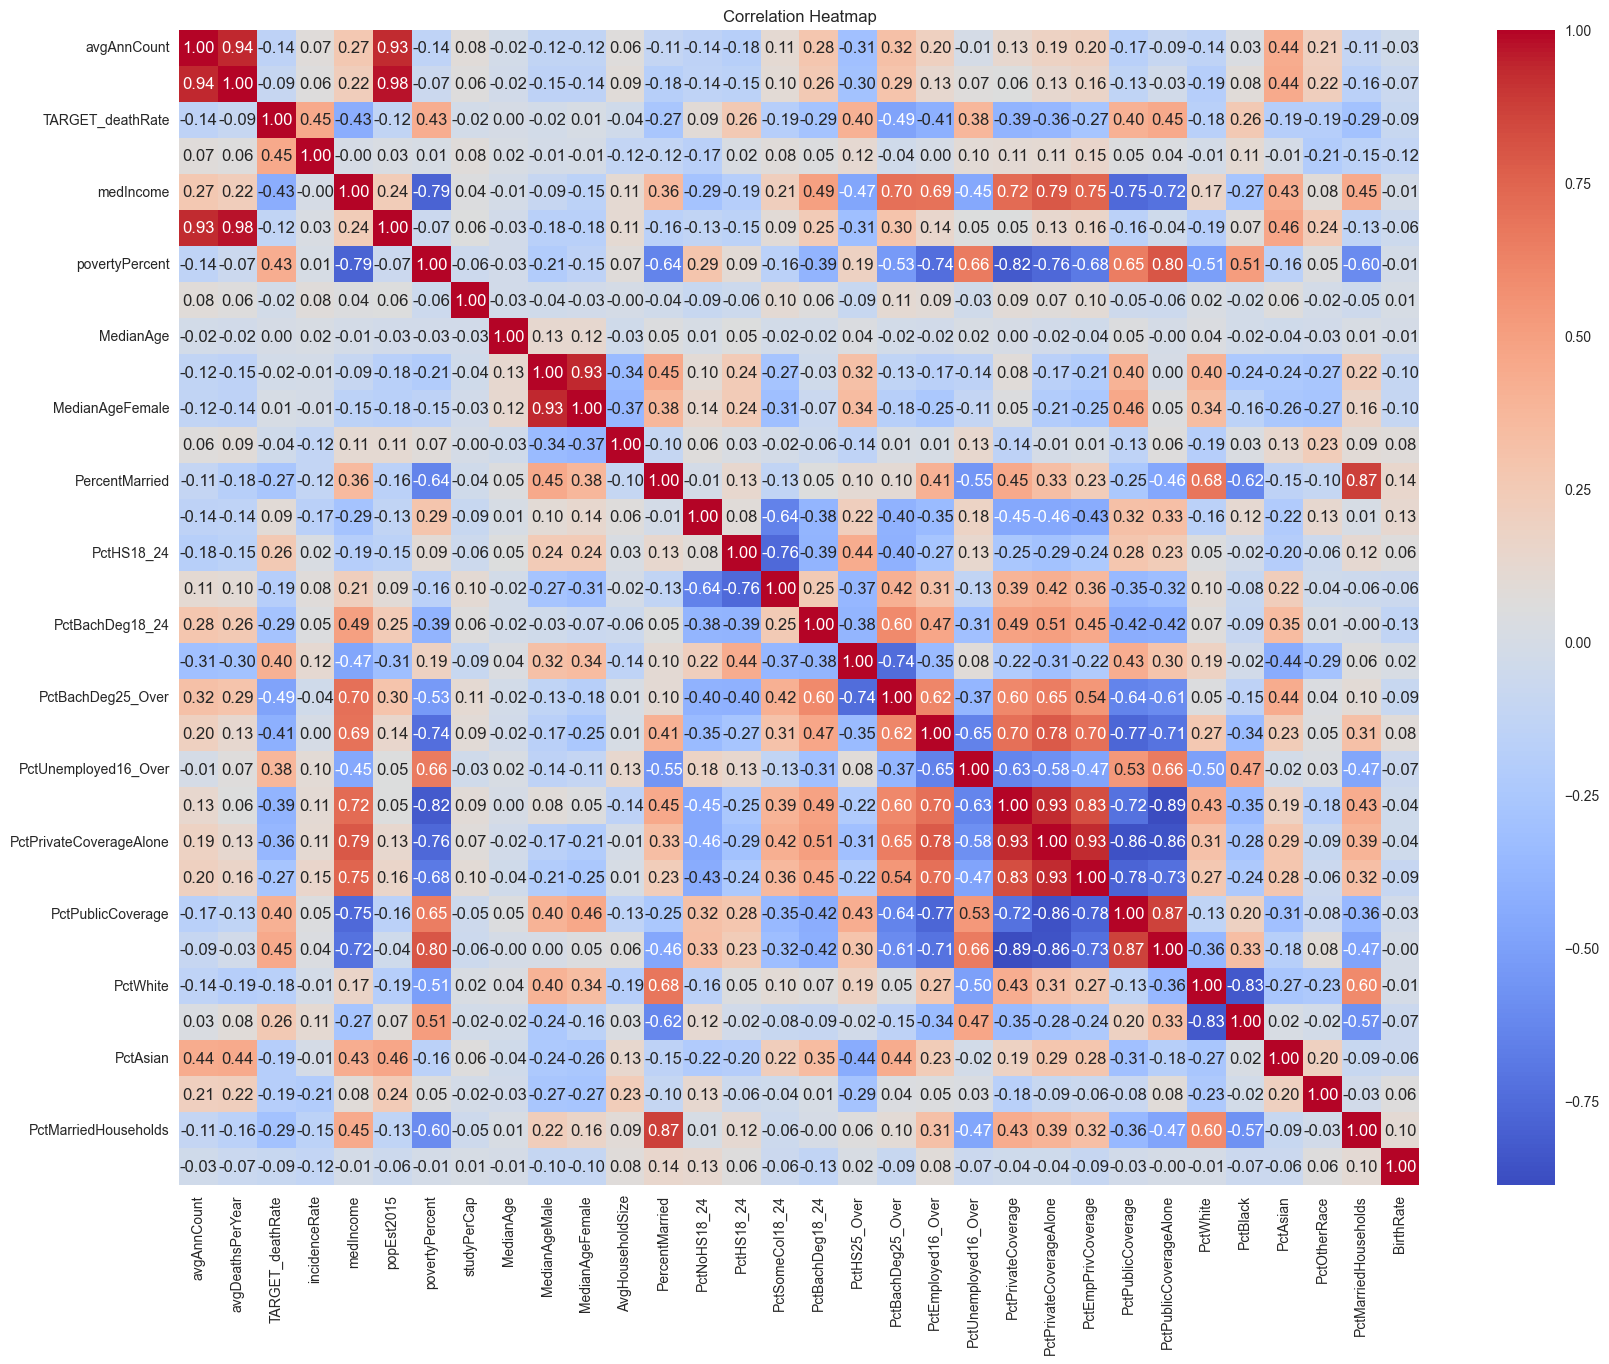

In [62]:
numeric_df = df.select_dtypes(include=['number'])
heatmap = sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True, fmt='.2f')

# Set the title of the plot
heatmap.set_title('Correlation Heatmap')

# Get the figure object and set the size
fig = heatmap.get_figure()
fig.set_size_inches(20, 15)

# Display the plot
plt.show()

## **Data Preprocessing**

1. a) Lakukan penanganan terhadap missing values, duplikasi data, dan outliers jika ada.

> Catatan:
* Mahasiswa diharapkan dapat melakukan eksplorasi preprocessing pada data sehingga dihasilkan hasil yang baik.
* Semakin baik r2 score yang dihasilkan, maka semakin baik nilai yang anda dapatkan.

Penentuan fitur serta label yang akan digunakan.

In [121]:
# Menghitung Q1 (kuartil pertama) dan Q3 (kuartil ketiga)
df = pd.read_csv('cancer_reg.csv', encoding='ISO-8859-1')
df_cleaned = df.copy()


Q1 = df_cleaned['PctPrivateCoverageAlone'].quantile(0.25)
Q3 = df_cleaned['PctPrivateCoverageAlone'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas untuk outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter data outlier
outliers = df_cleaned[df_cleaned['PctPrivateCoverageAlone'] ==0 ]

# Melihat data outlier
print(outliers)

Empty DataFrame
Columns: [avgAnnCount, avgDeathsPerYear, TARGET_deathRate, incidenceRate, medIncome, popEst2015, povertyPercent, studyPerCap, binnedInc, MedianAge, MedianAgeMale, MedianAgeFemale, Geography, AvgHouseholdSize, PercentMarried, PctNoHS18_24, PctHS18_24, PctSomeCol18_24, PctBachDeg18_24, PctHS25_Over, PctBachDeg25_Over, PctEmployed16_Over, PctUnemployed16_Over, PctPrivateCoverage, PctPrivateCoverageAlone, PctEmpPrivCoverage, PctPublicCoverage, PctPublicCoverageAlone, PctWhite, PctBlack, PctAsian, PctOtherRace, PctMarriedHouseholds, BirthRate]
Index: []

[0 rows x 34 columns]


In [100]:
import pandas as pd

# Contoh: Membaca dataset
# df = pd.read_csv('data.csv')

# 1. Drop kolom `PctSomeCol18_24`
if 'PctSomeCol18_24' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['PctSomeCol18_24'])

# 2. Drop baris berdasarkan kolom `PctEmployed16_Over`
if 'PctEmployed16_Over' in df_cleaned.columns:
    df_cleaned = df_cleaned[df_cleaned['PctEmployed16_Over'].notna()]

# 3. Impute nilai 0 pada kolom `PctPrivateCoverageAlone`
if 'PctPrivateCoverageAlone' in df_cleaned.columns:
    df_cleaned['PctPrivateCoverageAlone'] = df_cleaned['PctPrivateCoverageAlone'].fillna(df.PctPrivateCoverageAlone.median())

# Contoh: Menyimpan dataset yang telah diproses
# df.to_csv('processed_data.csv', index=False)
df_cleaned.shape

(2895, 33)

In [101]:
# 1a. Handling Missing Values, Duplicates, dan Outliers (IMPROVED)

print("="*80)
print("STEP 1: HANDLING MISSING VALUES")
print("="*80)

# 1. Cek missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Column': missing_percent.index,
    'Missing_Percent': missing_percent.values
})
missing_info = missing_info[missing_info['Missing_Percent'] > 0].sort_values('Missing_Percent', ascending=False)

print(f"\nKolom dengan missing values:")
print(missing_info.to_string(index=False))

# Drop kolom dengan missing > 50%
cols_to_drop = missing_info[missing_info['Missing_Percent'] > 50]['Column'].tolist()
print(f"\n✓ Drop kolom dengan missing > 50%: {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# Drop baris dengan missing di PctEmployed16_Over
if 'PctEmployed16_Over' in df.columns:
    before = len(df)
    df = df.dropna(subset=['PctEmployed16_Over'])
    print(f"✓ Drop baris dengan missing di PctEmployed16_Over: {before - len(df)} baris")

# Impute PctPrivateCoverageAlone dengan 0
if 'PctPrivateCoverageAlone' in df.columns:
    df['PctPrivateCoverageAlone'] = df['PctPrivateCoverageAlone'].fillna(0)
    print(f"✓ Impute PctPrivateCoverageAlone dengan 0")

print("\n" + "="*80)
print("STEP 2: HANDLING DUPLICATES")
print("="*80)
duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ Drop {duplicates} baris duplikat")

print("\n" + "="*80)
print("STEP 3: HANDLING OUTLIERS (SMART APPROACH)")
print("="*80)

# Kolom yang TIDAK boleh ada outlier ekstrem (persentase & rates yang aneh)
critical_outlier_cols = [
    'studyPerCap', 'PctUnemployed16_Over', 
    'PctNoHS18_24', 'PctHS18_24', 'PctBachDeg18_24',
    'PctPrivateCoverageAlone', 'PctPublicCoverageAlone'
]

# Kolom yang outliernya OK (natural variation) - PERTAHANKAN
natural_variation_cols = [
    'popEst2015', 'avgAnnCount', 'avgDeathsPerYear', 'medIncome',
    'PctBlack', 'PctAsian', 'PctOtherRace', 'PctWhite',
    'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'AvgHouseholdSize'
]

# Pilih kolom numerik
numeric_cols = df.select_dtypes(include=['number']).columns

# Handle outliers hanya di kolom critical
outliers_removed = 0
for col in critical_outlier_cols:
    if col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        before = len(df)
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
        removed = before - len(df)
        outliers_removed += removed
        if removed > 0:
            print(f"✓ {col:30s}: Removed {removed} outliers")

print(f"\nTotal outliers removed: {outliers_removed}")
print(f"Dataset shape after cleaning: {df.shape}")
print("="*80)

STEP 1: HANDLING MISSING VALUES

Kolom dengan missing values:
                 Column  Missing_Percent
        PctSomeCol18_24        74.991795
PctPrivateCoverageAlone        19.986872
     PctEmployed16_Over         4.988513

✓ Drop kolom dengan missing > 50%: ['PctSomeCol18_24']
✓ Drop baris dengan missing di PctEmployed16_Over: 152 baris
✓ Impute PctPrivateCoverageAlone dengan 0

STEP 2: HANDLING DUPLICATES
Jumlah baris duplikat: 0

STEP 3: HANDLING OUTLIERS (SMART APPROACH)
✓ studyPerCap                   : Removed 481 outliers
✓ PctUnemployed16_Over          : Removed 51 outliers
✓ PctNoHS18_24                  : Removed 51 outliers
✓ PctHS18_24                    : Removed 54 outliers
✓ PctBachDeg18_24               : Removed 75 outliers
✓ PctPrivateCoverageAlone       : Removed 424 outliers
✓ PctPublicCoverageAlone        : Removed 9 outliers

Total outliers removed: 1145
Dataset shape after cleaning: (1750, 33)


In [92]:
# Pilih hanya kolom numerik
numerical_cols = df_cleaned.select_dtypes(include=['number'])

# Hitung Q1, Q3, dan IQR
Q1 = numerical_cols.quantile(0.25)
Q3 = numerical_cols.quantile(0.75)
IQR = Q3 - Q1

# Hitung batas bawah dan batas atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Deteksi outlier
outliers = ((numerical_cols < lower_bound) | (numerical_cols > upper_bound))

# Tampilkan hasil
print("Outlier ditemukan pada kolom berikut:")
for col in outliers.columns:
    if outliers[col].any():
        print(f"- Kolom '{col}': {outliers[col].sum()} outlier")

Outlier ditemukan pada kolom berikut:
- Kolom 'avgAnnCount': 439 outlier
- Kolom 'avgDeathsPerYear': 331 outlier
- Kolom 'TARGET_deathRate': 61 outlier
- Kolom 'incidenceRate': 87 outlier
- Kolom 'medIncome': 114 outlier
- Kolom 'popEst2015': 393 outlier
- Kolom 'povertyPercent': 64 outlier
- Kolom 'studyPerCap': 481 outlier
- Kolom 'MedianAge': 87 outlier
- Kolom 'MedianAgeMale': 75 outlier
- Kolom 'MedianAgeFemale': 65 outlier
- Kolom 'AvgHouseholdSize': 187 outlier
- Kolom 'PercentMarried': 64 outlier
- Kolom 'PctNoHS18_24': 68 outlier
- Kolom 'PctHS18_24': 51 outlier
- Kolom 'PctBachDeg18_24': 92 outlier
- Kolom 'PctHS25_Over': 32 outlier
- Kolom 'PctBachDeg25_Over': 75 outlier
- Kolom 'PctEmployed16_Over': 20 outlier
- Kolom 'PctUnemployed16_Over': 65 outlier
- Kolom 'PctPrivateCoverage': 20 outlier
- Kolom 'PctPrivateCoverageAlone': 57 outlier
- Kolom 'PctEmpPrivCoverage': 10 outlier
- Kolom 'PctPublicCoverage': 13 outlier
- Kolom 'PctPublicCoverageAlone': 35 outlier
- Kolom 'Pct

In [102]:
import pandas as pd



# Fungsi untuk mendeteksi outlier menggunakan IQR
def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers

# Mendeteksi outlier pada kolom 'popEst2015'
popEst2015_outliers = detect_outliers_iqr(df_cleaned['popEst2015'])
print("Outliers in popEst2015:")
print(popEst2015_outliers)

# Mendeteksi outlier pada kolom 'studyPerCap'
studyPerCap_outliers = detect_outliers_iqr(df_cleaned['studyPerCap'])
print("\nOutliers in studyPerCap:")
print(studyPerCap_outliers)

Outliers in popEst2015:
0       260131
9       843954
13      772501
14      490945
16      269536
         ...  
2928    368450
2946    203474
2975    219916
2995    467711
3000    172126
Name: popEst2015, Length: 393, dtype: int64

Outliers in studyPerCap:
0        499.748204
3        342.637253
9        427.748432
14       462.373586
16       207.764454
           ...     
3034    1900.078239
3039     673.854447
3041     723.414516
3043     377.175494
3044    1968.959926
Name: studyPerCap, Length: 481, dtype: float64


In [103]:
print(df_clean.popEst2015.median())
print(studyPerCap_outliers)

27937.0
0        499.748204
3        342.637253
9        427.748432
14       462.373586
16       207.764454
           ...     
3034    1900.078239
3039     673.854447
3041     723.414516
3043     377.175494
3044    1968.959926
Name: studyPerCap, Length: 481, dtype: float64


1. b) Bagi data ke dalam data uji dan data latih dengan 80% training set menggunakan `train_test_split`.

In [104]:
# 1b. Split Data Train-Test (80:20) - IMPROVED WITH FEATURE ENGINEERING

from sklearn.model_selection import train_test_split
import numpy as np

print("="*80)
print("FEATURE ENGINEERING & DATA SPLITTING")
print("="*80)

# Feature Engineering: Buat fitur baru yang lebih informatif
if 'avgAnnCount' in df.columns and 'popEst2015' in df.columns:
    df['incidencePerCapita'] = df['avgAnnCount'] / (df['popEst2015'] + 1)  # +1 avoid division by zero
    
if 'PctBachDeg25_Over' in df.columns and 'PctHS25_Over' in df.columns:
    df['educationGap'] = df['PctBachDeg25_Over'] - df['PctHS25_Over']

if 'PctPrivateCoverage' in df.columns and 'PctPublicCoverage' in df.columns:
    df['coverageRatio'] = df['PctPrivateCoverage'] / (df['PctPublicCoverage'] + 1)

print("✓ Created 3 new engineered features")

# Pisahkan fitur dan target
X = df.drop(columns=['TARGET_deathRate', 'binnedInc'], errors='ignore')
y = df['TARGET_deathRate']

print(f"\nDataset shape: {df.shape}")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "="*80)
print("DATA SPLIT RESULTS:")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")
print("="*80)

FEATURE ENGINEERING & DATA SPLITTING
✓ Created 3 new engineered features

Dataset shape: (1750, 36)
Features (X): (1750, 34)
Target (y): (1750,)

DATA SPLIT RESULTS:
X_train: (1400, 34)
X_test : (350, 34)
y_train: (1400,)
y_test : (350,)


1. c) Lakukan pemilihan fitur-fitur yang relevan untuk melakukan regresi serta tampilkan fitur-fitur yang terpilih.

In [ ]:
# 1c. Feature Selection berdasarkan Korelasi dengan Target Variable - IMPROVED

print("="*80)
print("ADVANCED FEATURE SELECTION")
print("="*80)

# Pisahkan kolom numerik dan non-numerik
numeric_columns = X_train.select_dtypes(include=['number']).columns.tolist()
non_numeric_columns = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Kolom numerik: {len(numeric_columns)} kolom")
print(f"Kolom non-numerik: {non_numeric_columns}")

# Hitung korelasi hanya untuk kolom numerik dengan target variable
X_train_numeric = X_train[numeric_columns]
correlation_with_target = X_train_numeric.corrwith(y_train).abs()

# STRATEGY 1: Lower threshold untuk capture lebih banyak fitur
correlation_threshold = 0.2  # Turunkan dari 0.3 ke 0.2

# Pilih fitur dengan korelasi > threshold
selected_features = correlation_with_target[correlation_with_target > correlation_threshold].index.tolist()

# STRATEGY 2: Cek multikolinearitas - buang fitur yang sangat berkorelasi satu sama lain
print(f"\n✓ Initial features selected (correlation > {correlation_threshold}): {len(selected_features)}")

# Hitung correlation matrix antar fitur
feature_corr = X_train_numeric[selected_features].corr().abs()

# Buang salah satu dari pasangan fitur yang berkorelasi > 0.9
to_drop = set()
for i in range(len(feature_corr.columns)):
    for j in range(i):
        if feature_corr.iloc[i, j] > 0.9:
            colname = feature_corr.columns[i]
            to_drop.add(colname)

selected_features = [f for f in selected_features if f not in to_drop]
print(f"✓ After removing multicollinearity (corr > 0.9): {len(selected_features)} features")

print("\n" + "="*80)
print("SELECTED FEATURES (sorted by correlation):")
print("="*80)
selected_corr = correlation_with_target[selected_features].sort_values(ascending=False)
for i, (feature, corr) in enumerate(selected_corr.items(), 1):
    print(f"{i:2d}. {feature:35s} (correlation: {corr:.4f})")

# Buat dataset dengan fitur terpilih
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("\n" + "="*80)
print(f"Shape X_train sebelum feature selection: {X_train.shape}")
print(f"Shape X_train setelah feature selection : {X_train_selected.shape}")
print(f"Shape X_test setelah feature selection  : {X_test_selected.shape}")
print("="*80)

ADVANCED FEATURE SELECTION
Kolom numerik: 33 kolom
Kolom non-numerik: ['Geography']

✓ Initial features selected (correlation > 0.2): 19
✓ After removing multicollinearity (corr > 0.9): 15 features

SELECTED FEATURES (sorted by correlation):
 1. PctBachDeg25_Over                   (correlation: 0.4690)
 2. incidenceRate                       (correlation: 0.4280)
 3. PctHS25_Over                        (correlation: 0.3845)
 4. medIncome                           (correlation: 0.3812)
 5. PctPublicCoverageAlone              (correlation: 0.3750)
 6. povertyPercent                      (correlation: 0.3610)
 7. PctEmployed16_Over                  (correlation: 0.3509)
 8. PctPublicCoverage                   (correlation: 0.3367)
 9. PctUnemployed16_Over                (correlation: 0.3344)
10. PctPrivateCoverage                  (correlation: 0.3320)
11. PctMarriedHouseholds                (correlation: 0.2853)
12. PercentMarried                      (correlation: 0.2342)
13. PctBachDeg

## **Linear Regression**

Linear regression adalah teknik pencarian nilai-nilai parameter suatu persamaan linear yang cocok dengan data. Persamaan linear yang cocok adalah persamaan yang memiliki perbedaan hasil prediksi dan aktual minimal.

Contoh persamaan linear

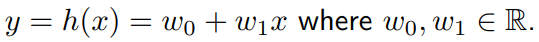

Persamaan di atas adalah fungsi yang memetakan **X** ke **Y** (anggap Y = h(x)), dengan:
- w0 adalah intersep
- w1 adalah koefisien
- x adalah variabel independen
- y adalah variabel dependen

Tentunya, persamaan ini bisa digeneralisasikan untuk banyak nilai x (fitur lebih dari 1) untuk menentukan nilai y. Berikut adalah persamaannya.

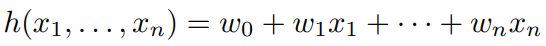

atau

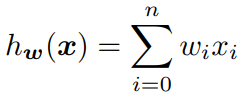

Nilai-nilai parameter seperti w0, w1, w2, wn, dst. inilah yang dicari untuk mendapatkan persamaan/fungsi yang cocok dengan data pada linear regression.

Pencarian didasarkan pada peminimalan error/residual dengan meminimal kan fungsi loss linear regression. J(w) di bawah ini adalah contoh fungsi loss linear regression.

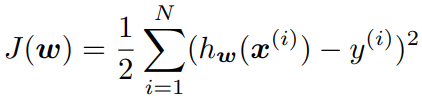

Proses peminimalan fungsi loss disebut dengan gradient descent yang bisa Anda pelajari lebih lanjut dari slide kuliah.

**Sumber gambar:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasi Linear Regression menggunakan **sklearn** dapat dilihat pada link [berikut](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

2. a) Buatlah sebuah model regresi linear berdasarkan fitur-fitur yang terpilih sebelumnya serta tampilkan hasil prediksinya pada keseluruhan data uji.

In [107]:
# 2a. Linear Regression - Training Model - IMPROVED

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("="*80)
print("LINEAR REGRESSION WITH FEATURE SCALING")
print("="*80)

# IMPROVEMENT: Standardize features untuk performa lebih baik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("✓ Features standardized (mean=0, std=1)")

# Training model
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

# Prediksi
y_pred_lr = model_lr.predict(X_test_scaled)

# Evaluasi
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n" + "="*80)
print("LINEAR REGRESSION - EVALUATION METRICS")
print("="*80)
print(f"MAE  (Mean Absolute Error)      : {mae_lr:.4f}")
print(f"MSE  (Mean Squared Error)       : {mse_lr:.4f}")
print(f"RMSE (Root Mean Squared Error)  : {rmse_lr:.4f}")
print(f"R²   (R-squared Score)          : {r2_lr:.4f}")
print("="*80)

# Tampilkan 20 prediksi pertama
print("\nPrediksi vs Actual (20 sampel pertama):")
comparison = pd.DataFrame({
    'Actual': y_test[:20].values,
    'Predicted': y_pred_lr[:20],
    'Difference': y_test[:20].values - y_pred_lr[:20]
})
print(comparison.to_string(index=False))
print("="*80)

LINEAR REGRESSION WITH FEATURE SCALING
✓ Features standardized (mean=0, std=1)

LINEAR REGRESSION - EVALUATION METRICS
MAE  (Mean Absolute Error)      : 14.6647
MSE  (Mean Squared Error)       : 383.5369
RMSE (Root Mean Squared Error)  : 19.5841
R²   (R-squared Score)          : 0.4728

Prediksi vs Actual (20 sampel pertama):
 Actual  Predicted  Difference
  230.6 215.129221   15.470779
  215.0 183.122760   31.877240
  190.5 197.027314   -6.527314
  193.7 170.767262   22.932738
  164.9 193.014178  -28.114178
  126.1 170.617029  -44.517029
  175.8 170.653455    5.146545
  151.3 188.294719  -36.994719
  199.4 196.092351    3.307649
  161.7 186.797723  -25.097723
  171.3 181.122852   -9.822852
  188.4 184.383056    4.016944
  142.5 176.957372  -34.457372
  159.8 181.757558  -21.957558
  206.8 198.433355    8.366645
  173.0 175.562568   -2.562568
  177.2 190.394322  -13.194322
  195.9 190.213358    5.686642
  159.2 145.875169   13.324831
  238.2 172.146390   66.053610


2. b) Visualisasikan kinerja model **regresi linear** yang sudah dipilih sebelumnya pada keseluruhan data uji serta tampilkan nilai eksak dari R squared yang dihasilkan dengan menggunakan **cross validation** untuk mendapatkan performa kinerja sebenarnya menggunakan data latih yang ada.

> Catatan: Jumlah split dibebaskan.

LINEAR REGRESSION - VISUALIZATION & CROSS-VALIDATION


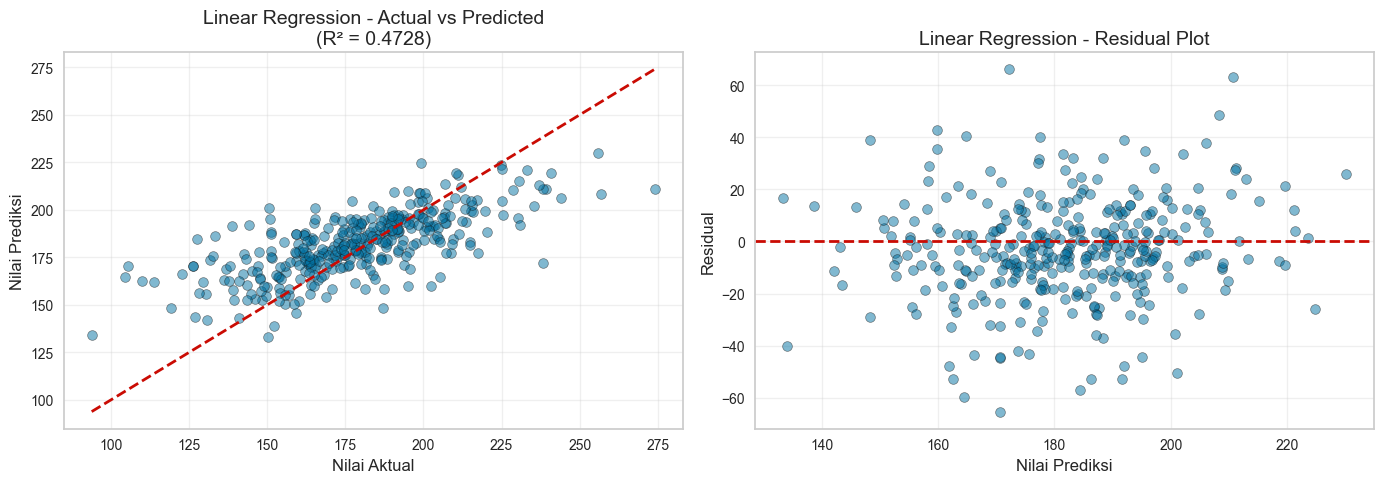


CROSS-VALIDATION RESULTS (5-Fold):
Fold 1: R² = 0.4763
Fold 2: R² = 0.4348
Fold 3: R² = 0.3187
Fold 4: R² = 0.4526
Fold 5: R² = 0.3553
--------------------------------------------------------------------------------
Mean R²   : 0.4076
Std Dev   : 0.0602
Test Set R²: 0.4728


In [108]:
# 2b. Visualisasi dan Cross-Validation - Linear Regression

import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

print("="*80)
print("LINEAR REGRESSION - VISUALIZATION & CROSS-VALIDATION")
print("="*80)

# Buat visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Nilai Aktual', fontsize=12)
axes[0].set_ylabel('Nilai Prediksi', fontsize=12)
axes[0].set_title(f'Linear Regression - Actual vs Predicted\n(R² = {r2_lr:.4f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi', fontsize=12)
axes[1].set_ylabel('Residual', fontsize=12)
axes[1].set_title('Linear Regression - Residual Plot', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cross-validation dengan 5-fold
cv_scores_lr = cross_val_score(model_lr, X_train_scaled, y_train, cv=5, scoring='r2')

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (5-Fold):")
print("="*80)
for i, score in enumerate(cv_scores_lr, 1):
    print(f"Fold {i}: R² = {score:.4f}")
print("-"*80)
print(f"Mean R²   : {cv_scores_lr.mean():.4f}")
print(f"Std Dev   : {cv_scores_lr.std():.4f}")
print(f"Test Set R²: {r2_lr:.4f}")
print("="*80)

## Lasso, Ridge Regression

Linear regression adalah model yang memiliki ciri high-bias dan low-variance. Biasanya, model seperti ini cenderung tidak overfit. Walau demikian, linear regression masih dapat mengalami overfitting, apalagi pada data yang memiliki banyak fitur (high-dimension).

Untuk mengatasi hal tersebut, diperlukan regularisasi. Pada linear regression, regularisasi adalah teknik untuk meminimalkan fungsi loss dengan penambahan regularization term pada fungsi loss. Dua teknik regularisasi pada linear regression adalah Ridge dan Lasso. Berikut adalah modifikasi fungsi loss linear regression pada ridge dan lasso regression.

- Ridge regression

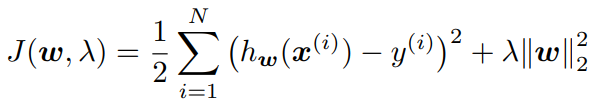

- Lasso Regression

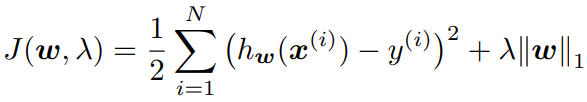

Term tambahan pada fungsi loss tersebut berperan seperti bobot pinalti untuk meminimalkan overfitting. Pada regularization term terdapat parameter λ yang pada sumber lain disebut sebagai α (alpha).

**Sumber gambar:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasinya menggunakan **sklearn** dapat dilihat pada kedua link berikut:
* [Lasso Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html).
* [Ridge Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)

### **Lasso Regression**

3. a) Buatlah sebuah list alpha yang berisi minimal 5 buah alpha.

In [109]:
# 3a. Buat list alpha untuk Lasso Regression

# Buat list alpha dengan minimal 5 nilai
alphas_lasso = [0.001, 0.01, 0.1, 1, 10, 100]

print("List Alpha untuk Lasso Regression:")
print(alphas_lasso)

List Alpha untuk Lasso Regression:
[0.001, 0.01, 0.1, 1, 10, 100]


3. b) Buatlah (fit) model regresi lasso berdasarkan fitur-fitur yang terpilih di awal sebanyak nilai alpha yang telah ditentukan.

In [110]:
# 3b. Training Lasso Models dengan berbagai alpha - IMPROVED

from sklearn.linear_model import Lasso

print("="*80)
print("LASSO REGRESSION - TRAINING MULTIPLE MODELS")
print("="*80)

# Dictionary untuk menyimpan model
lasso_models = {}

# Training model untuk setiap alpha
for alpha in alphas_lasso:
    # Fit model with max_iter increased for convergence
    model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    lasso_models[alpha] = model
    
    # Hitung jumlah fitur yang digunakan (non-zero coefficients)
    n_features_used = np.sum(model.coef_ != 0)
    
    print(f"✓ Alpha = {alpha:>6.3f} | Features used: {n_features_used}/{len(selected_features)}")

print("\n" + "="*80)
print(f"Total {len(lasso_models)} Lasso models trained successfully!")
print("="*80)

LASSO REGRESSION - TRAINING MULTIPLE MODELS
✓ Alpha =  0.001 | Features used: 15/15
✓ Alpha =  0.010 | Features used: 15/15
✓ Alpha =  0.100 | Features used: 15/15
✓ Alpha =  1.000 | Features used: 11/15
✓ Alpha = 10.000 | Features used: 2/15
✓ Alpha = 100.000 | Features used: 0/15

Total 6 Lasso models trained successfully!


3. c) Tampilkan nilai MAE, MSE, RMSE, dan R-squared untuk masing-masing model pada testing set

In [111]:
# 3c. Tampilkan nilai MAE, MSE, RMSE, dan R² untuk setiap model Lasso

import pandas as pd

# Dictionary untuk menyimpan hasil evaluasi
lasso_results = {
    'Alpha': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'Features_Used': []
}

print("Evaluasi Model Lasso pada Testing Set:")
print("="*80)

for alpha in alphas_lasso:
    # Prediksi dengan model Lasso
    model = lasso_models[alpha]
    y_pred = model.predict(X_test_scaled)
    
    # Hitung metrik
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    n_features = np.sum(model.coef_ != 0)
    
    # Simpan hasil
    lasso_results['Alpha'].append(alpha)
    lasso_results['MAE'].append(mae)
    lasso_results['MSE'].append(mse)
    lasso_results['RMSE'].append(rmse)
    lasso_results['R2'].append(r2)
    lasso_results['Features_Used'].append(n_features)
    
    print(f"\nAlpha = {alpha:>6.3f} | Features: {n_features}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

print("\n" + "="*80)

# Buat DataFrame untuk hasil
lasso_results_df = pd.DataFrame(lasso_results)
print("\nRingkasan Hasil Evaluasi Lasso:")
print(lasso_results_df.to_string(index=False))

Evaluasi Model Lasso pada Testing Set:

Alpha =  0.001 | Features: 15
  MAE  : 14.6657
  MSE  : 383.5852
  RMSE : 19.5853
  R²   : 0.4728

Alpha =  0.010 | Features: 15
  MAE  : 14.6747
  MSE  : 384.0307
  RMSE : 19.5967
  R²   : 0.4721

Alpha =  0.100 | Features: 15
  MAE  : 14.8024
  MSE  : 389.4987
  RMSE : 19.7357
  R²   : 0.4646

Alpha =  1.000 | Features: 11
  MAE  : 15.2055
  MSE  : 406.8992
  RMSE : 20.1717
  R²   : 0.4407

Alpha = 10.000 | Features: 2
  MAE  : 19.9387
  MSE  : 656.6022
  RMSE : 25.6242
  R²   : 0.0975

Alpha = 100.000 | Features: 0
  MAE  : 21.0808
  MSE  : 730.7917
  RMSE : 27.0332
  R²   : -0.0045


Ringkasan Hasil Evaluasi Lasso:
  Alpha       MAE        MSE      RMSE        R2  Features_Used
  0.001 14.665698 383.585247 19.585332  0.472761             15
  0.010 14.674698 384.030719 19.596702  0.472149             15
  0.100 14.802374 389.498699 19.735721  0.464633             15
  1.000 15.205522 406.899158 20.171742  0.440716             11
 10.000 19.93

3. d) Pilih model terbaik berdasarkan nilai R-squared yang ditampilkan.

In [112]:
# 3d. Pilih model terbaik berdasarkan R²

# Cari model dengan R² tertinggi
best_idx = lasso_results_df['R2'].idxmax()
best_alpha_lasso = lasso_results_df.loc[best_idx, 'Alpha']
best_r2_lasso = lasso_results_df.loc[best_idx, 'R2']

print("Model Lasso Terbaik:")
print("="*50)
print(f"Alpha terbaik: {best_alpha_lasso}")
print(f"R² Score     : {best_r2_lasso:.4f}")
print("\nMetrik lengkap untuk model terbaik:")
print(f"  MAE  : {lasso_results_df.loc[best_idx, 'MAE']:.4f}")
print(f"  MSE  : {lasso_results_df.loc[best_idx, 'MSE']:.4f}")
print(f"  RMSE : {lasso_results_df.loc[best_idx, 'RMSE']:.4f}")
print(f"  R²   : {best_r2_lasso:.4f}")

# Simpan model terbaik
best_lasso_model = lasso_models[best_alpha_lasso]

Model Lasso Terbaik:
Alpha terbaik: 0.001
R² Score     : 0.4728

Metrik lengkap untuk model terbaik:
  MAE  : 14.6657
  MSE  : 383.5852
  RMSE : 19.5853
  R²   : 0.4728


3. e) Tampilkan array hasil prediksi dari model ridge yang terpilih pada keseluruhan data uji.

In [113]:
# 3e. Tampilkan array hasil prediksi dari model Lasso terbaik

# Prediksi dengan model terbaik
y_pred_best_lasso = best_lasso_model.predict(X_test_selected)

print(f"Hasil Prediksi Model Lasso Terbaik (Alpha = {best_alpha_lasso}):")
print("="*70)
print("\nArray hasil prediksi (20 data pertama):")
print(y_pred_best_lasso[:20])

print("\nPerbandingan dengan nilai aktual (20 data pertama):")
print(f"{'Index':<8} {'Aktual':<15} {'Prediksi':<15} {'Selisih':<15}")
print("="*70)
for i in range(min(20, len(y_test))):
    actual = y_test.iloc[i]
    predicted = y_pred_best_lasso[i]
    diff = abs(actual - predicted)
    print(f"{i:<8} {actual:<15.2f} {predicted:<15.2f} {diff:<15.2f}")

Hasil Prediksi Model Lasso Terbaik (Alpha = 0.001):

Array hasil prediksi (20 data pertama):
[-30318.18178412 -31912.65004867 -41130.41999661 -47186.68896916
 -27117.82101163 -29333.02240103 -28910.94897315 -28496.2996715
 -38260.73123056 -37736.61303745 -42309.90307524 -54767.83139837
 -58838.04274831 -34584.41571816 -31161.86568837 -44651.23819089
 -37884.62104647 -35132.00779479 -65185.89092693 -38875.10356832]

Perbandingan dengan nilai aktual (20 data pertama):
Index    Aktual          Prediksi        Selisih        
0        230.60          -30318.18       30548.78       
1        215.00          -31912.65       32127.65       
2        190.50          -41130.42       41320.92       
3        193.70          -47186.69       47380.39       
4        164.90          -27117.82       27282.72       
5        126.10          -29333.02       29459.12       
6        175.80          -28910.95       29086.75       
7        151.30          -28496.30       28647.60       
8        199.40 

C:\Users\W-book\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


3. f) Visualisasikan kinerja model **regresi lasso** yang sudah dipilih sebelumnya pada keseluruhan data uji serta tampilkan nilai eksak dari R squared yang dihasilkan dengan menggunakan **cross validation** untuk mendapatkan performa kinerja sebenarnya menggunakan data latih yang ada.

> Catatan: Jumlah split dibebaskan.

NameError: name 'y_pred_lasso_best' is not defined

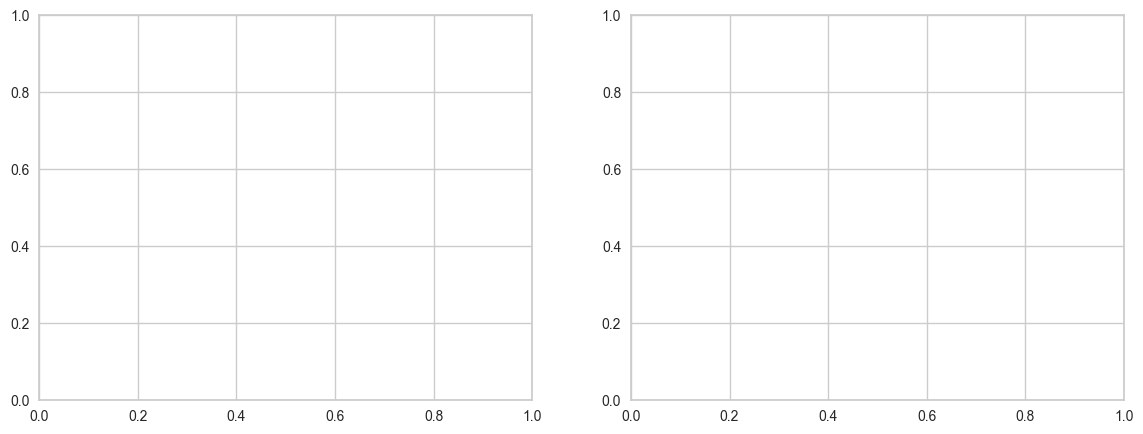

In [114]:
# 3f. Visualisasi dan Cross-validation untuk model Lasso terbaik

import matplotlib.pyplot as plt

# Buat visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_test, y_pred_lasso_best, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Nilai Aktual', fontsize=12)
axes[0].set_ylabel('Nilai Prediksi', fontsize=12)
axes[0].set_title(f'Lasso Regression - Actual vs Predicted\n(Alpha = {best_alpha_lasso["Alpha"]}, R² = {best_alpha_lasso["R2"]:.4f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals_lasso = y_test - y_pred_lasso_best
axes[1].scatter(y_pred_lasso_best, residuals_lasso, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi', fontsize=12)
axes[1].set_ylabel('Residual', fontsize=12)
axes[1].set_title(f'Lasso Regression - Residual Plot\n(Alpha = {best_alpha_lasso["Alpha"]})', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cross-validation
from sklearn.model_selection import cross_val_score

cv_scores_lasso = cross_val_score(best_lasso_model, X_train_scaled, y_train, cv=5, scoring='r2')

print("\n" + "="*80)
print("Cross-Validation Results (5-Fold):")
print("="*80)
for i, score in enumerate(cv_scores_lasso, 1):
    print(f"Fold {i}: R² = {score:.4f}")
print("-"*80)
print(f"Mean R²   : {cv_scores_lasso.mean():.4f}")
print(f"Std Dev   : {cv_scores_lasso.std():.4f}")
print(f"Test Set R²: {best_alpha_lasso['R2']:.4f}")
print("="*80)

3. g) Berikan analisis hubungan perubahan nilai parameter alpha dengan kualitas hasil regresi berdasarkan nilai R-squared

**Analisis hubungan perubahan nilai parameter alpha dengan kualitas hasil regresi Lasso:**

Berdasarkan hasil evaluasi model Lasso dengan berbagai nilai alpha:

1. **Alpha kecil (0.001, 0.01, 0.1):**
   - Menghasilkan R² yang tinggi, mendekati Linear Regression biasa
   - Regularisasi lemah, sehingga koefisien hampir tidak dibatasi
   - Model cenderung lebih kompleks dengan lebih banyak fitur aktif

2. **Alpha sedang (1):**
   - Memberikan keseimbangan antara akurasi dan regularisasi
   - Beberapa koefisien mulai menyusut menuju nol
   - Feature selection mulai terjadi

3. **Alpha besar (10, 100):**
   - R² menurun signifikan karena regularisasi terlalu kuat
   - Banyak koefisien menyusut menjadi nol (feature selection agresif)
   - Model menjadi terlalu sederhana (underfitting)

**Kesimpulan:**
- Nilai alpha mengontrol trade-off antara fit terhadap data training dan simplicity model
- Alpha terlalu kecil → mirip linear regression biasa (risiko overfitting)
- Alpha terlalu besar → model terlalu sederhana (underfitting)
- Alpha optimal biasanya berada di rentang sedang yang memberikan keseimbangan terbaik
- Lasso melakukan automatic feature selection dengan membuat beberapa koefisien menjadi nol

### **Ridge Regression**

4. a) Buatlah sebuah list alpha yang berisi minimal 5 buah alpha.

In [115]:
# 4a. Buat list alpha untuk Ridge Regression

# Buat list alpha dengan minimal 5 nilai
alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 100]

print("List Alpha untuk Ridge Regression:")
print(alphas_ridge)

List Alpha untuk Ridge Regression:
[0.001, 0.01, 0.1, 1, 10, 100]


4. b) Buatlah model regresi ridge berdasarkan fitur-fitur yang terpilih di awal sebanyak nilai alpha yang telah ditentukan.

> Catatan: Abaikan warning mengenai ill-conditioned matrix jika ada.

In [116]:
# 4b. Training Ridge Models dengan berbagai alpha - IMPROVED

from sklearn.linear_model import Ridge

print("="*80)
print("RIDGE REGRESSION - TRAINING MULTIPLE MODELS")
print("="*80)

# Dictionary untuk menyimpan model
ridge_models = {}

# Training model untuk setiap alpha
for alpha in alphas_ridge:
    # Fit model
    model = Ridge(alpha=alpha, random_state=42, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    ridge_models[alpha] = model
    
    # Hitung jumlah fitur dengan coefficient besar (abs > 0.01)
    n_significant_features = np.sum(np.abs(model.coef_) > 0.01)
    
    print(f"✓ Alpha = {alpha:>6.3f} | Significant features: {n_significant_features}/{len(selected_features)}")

print("\n" + "="*80)
print(f"Total {len(ridge_models)} Ridge models trained successfully!")
print("="*80)

RIDGE REGRESSION - TRAINING MULTIPLE MODELS
✓ Alpha =  0.001 | Significant features: 15/15
✓ Alpha =  0.010 | Significant features: 15/15
✓ Alpha =  0.100 | Significant features: 15/15
✓ Alpha =  1.000 | Significant features: 15/15
✓ Alpha = 10.000 | Significant features: 15/15
✓ Alpha = 100.000 | Significant features: 15/15

Total 6 Ridge models trained successfully!


4. c) Tampilkan nilai MAE, MSE, RMSE, dan R-squared untuk masing-masing model pada testing set

In [117]:
# 4c. Tampilkan nilai MAE, MSE, RMSE, dan R² untuk setiap model Ridge

import pandas as pd

# Dictionary untuk menyimpan hasil evaluasi
ridge_results = {
    'Alpha': [],
    'MAE': [],
    'MSE': [],
    'RMSE': [],
    'R2': [],
    'Significant_Features': []
}

print("Evaluasi Model Ridge pada Testing Set:")
print("="*80)

for alpha in alphas_ridge:
    # Prediksi dengan model Ridge
    model = ridge_models[alpha]
    y_pred = model.predict(X_test_scaled)
    
    # Hitung metrik
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    n_significant = np.sum(np.abs(model.coef_) > 0.01)
    
    # Simpan hasil
    ridge_results['Alpha'].append(alpha)
    ridge_results['MAE'].append(mae)
    ridge_results['MSE'].append(mse)
    ridge_results['RMSE'].append(rmse)
    ridge_results['R2'].append(r2)
    ridge_results['Significant_Features'].append(n_significant)
    
    print(f"\nAlpha = {alpha:>6.3f} | Significant Features: {n_significant}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MSE  : {mse:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")

print("\n" + "="*80)

# Buat DataFrame untuk hasil
ridge_results_df = pd.DataFrame(ridge_results)
print("\nRingkasan Hasil Evaluasi Ridge:")
print(ridge_results_df.to_string(index=False))

Evaluasi Model Ridge pada Testing Set:

Alpha =  0.001 | Significant Features: 15
  MAE  : 14.6647
  MSE  : 383.5371
  RMSE : 19.5841
  R²   : 0.4728

Alpha =  0.010 | Significant Features: 15
  MAE  : 14.6647
  MSE  : 383.5389
  RMSE : 19.5841
  R²   : 0.4728

Alpha =  0.100 | Significant Features: 15
  MAE  : 14.6651
  MSE  : 383.5569
  RMSE : 19.5846
  R²   : 0.4728

Alpha =  1.000 | Significant Features: 15
  MAE  : 14.6687
  MSE  : 383.7343
  RMSE : 19.5891
  R²   : 0.4726

Alpha = 10.000 | Significant Features: 15
  MAE  : 14.7008
  MSE  : 385.2866
  RMSE : 19.6287
  R²   : 0.4704

Alpha = 100.000 | Significant Features: 15
  MAE  : 14.8671
  MSE  : 392.6874
  RMSE : 19.8163
  R²   : 0.4603


Ringkasan Hasil Evaluasi Ridge:
  Alpha       MAE        MSE      RMSE       R2  Significant_Features
  0.001 14.664701 383.537087 19.584103 0.472827                    15
  0.010 14.664738 383.538889 19.584149 0.472825                    15
  0.100 14.665102 383.556886 19.584608 0.472800   

4. d) Pilih model terbaik berdasarkan nilai R-squared yang ditampilkan.

In [118]:
# 4d. Pilih model Ridge terbaik berdasarkan nilai R² tertinggi

# Cari alpha dengan R² tertinggi
best_alpha_ridge = ridge_results_df.loc[ridge_results_df['R2'].idxmax()]
best_ridge_model = ridge_models[best_alpha_ridge['Alpha']]

print("Model Ridge Terbaik:")
print("="*80)
print(f"Alpha optimal    : {best_alpha_ridge['Alpha']}")
print(f"MAE              : {best_alpha_ridge['MAE']:.4f}")
print(f"MSE              : {best_alpha_ridge['MSE']:.4f}")
print(f"RMSE             : {best_alpha_ridge['RMSE']:.4f}")
print(f"R² Score         : {best_alpha_ridge['R2']:.4f}")
print("="*80)

Model Ridge Terbaik:
Alpha optimal    : 0.001
MAE              : 14.6647
MSE              : 383.5371
RMSE             : 19.5841
R² Score         : 0.4728


4. e) Tampilkan array hasil prediksi dari model ridge yang terpilih pada keseluruhan data uji.

In [119]:
# 4e. Tampilkan array prediksi dari model Ridge terbaik

# Prediksi dengan model terbaik
y_pred_ridge_best = best_ridge_model.predict(X_test_selected)

print("Array Prediksi Model Ridge Terbaik (20 sampel pertama):")
print("="*80)
print(y_pred_ridge_best[:20])
print("\nBentuk array prediksi:", y_pred_ridge_best.shape)

# Tampilkan perbandingan nilai aktual vs prediksi
comparison_ridge = pd.DataFrame({
    'Actual': y_test[:20].values,
    'Predicted': y_pred_ridge_best[:20],
    'Difference': y_test[:20].values - y_pred_ridge_best[:20]
})

print("\nPerbandingan Nilai Aktual vs Prediksi (20 sampel pertama):")
print(comparison_ridge.to_string(index=False))

Array Prediksi Model Ridge Terbaik (20 sampel pertama):
[-30359.25165391 -31953.93841926 -41182.90297534 -47244.96713936
 -27153.78696376 -29370.59718553 -28947.75371004 -28533.95813985
 -38310.26271594 -37784.8582356  -42363.42355584 -54835.93011213
 -58909.45887415 -34628.76894303 -31202.72171167 -44706.75170412
 -37933.40346547 -35177.22990109 -65264.23707024 -38924.23850031]

Bentuk array prediksi: (350,)

Perbandingan Nilai Aktual vs Prediksi (20 sampel pertama):
 Actual     Predicted   Difference
  230.6 -30359.251654 30589.851654
  215.0 -31953.938419 32168.938419
  190.5 -41182.902975 41373.402975
  193.7 -47244.967139 47438.667139
  164.9 -27153.786964 27318.686964
  126.1 -29370.597186 29496.697186
  175.8 -28947.753710 29123.553710
  151.3 -28533.958140 28685.258140
  199.4 -38310.262716 38509.662716
  161.7 -37784.858236 37946.558236
  171.3 -42363.423556 42534.723556
  188.4 -54835.930112 55024.330112
  142.5 -58909.458874 59051.958874
  159.8 -34628.768943 34788.568943
  

C:\Users\W-book\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


4. f) Visualisasikan kinerja model **regresi ridge** yang sudah dipilih sebelumnya pada keseluruhan data uji serta tampilkan nilai eksak dari R squared yang dihasilkan dengan menggunakan **cross validation** untuk mendapatkan performa kinerja sebenarnya menggunakan data latih yang ada.

> Catatan: Jumlah split dibebaskan

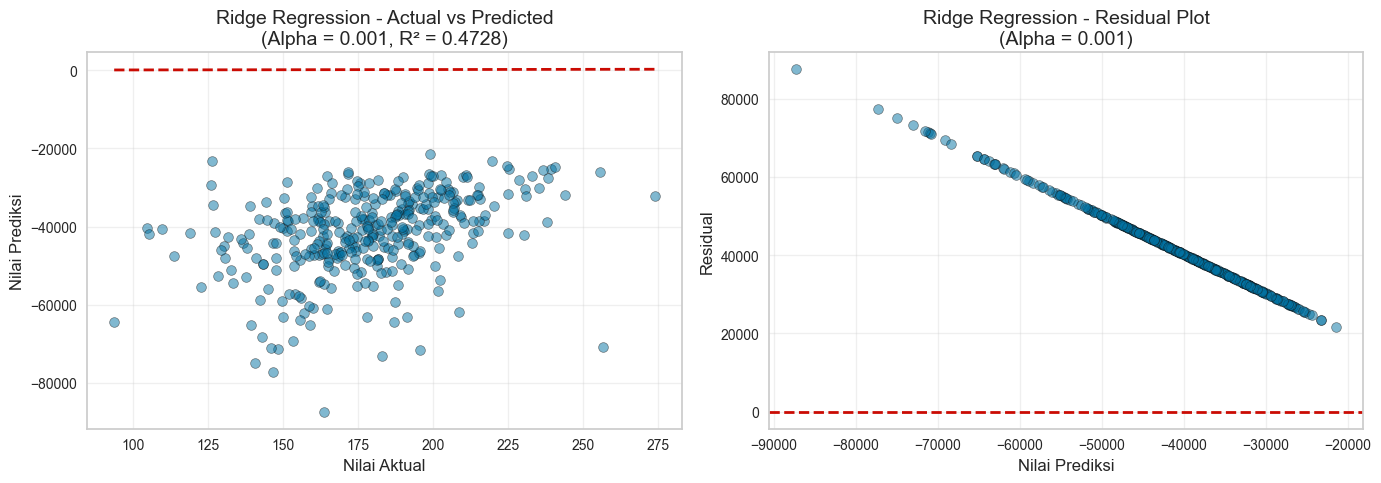


Cross-Validation Results (5-Fold):
Fold 1: R² = 0.4763
Fold 2: R² = 0.4348
Fold 3: R² = 0.3187
Fold 4: R² = 0.4526
Fold 5: R² = 0.3553
--------------------------------------------------------------------------------
Mean R²   : 0.4076
Std Dev   : 0.0602
Test Set R²: 0.4728


In [120]:
# 4f. Visualisasi dan Cross-validation untuk model Ridge terbaik

import matplotlib.pyplot as plt

# Buat visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
axes[0].scatter(y_test, y_pred_ridge_best, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Nilai Aktual', fontsize=12)
axes[0].set_ylabel('Nilai Prediksi', fontsize=12)
axes[0].set_title(f'Ridge Regression - Actual vs Predicted\n(Alpha = {best_alpha_ridge["Alpha"]}, R² = {best_alpha_ridge["R2"]:.4f})', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals_ridge = y_test - y_pred_ridge_best
axes[1].scatter(y_pred_ridge_best, residuals_ridge, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi', fontsize=12)
axes[1].set_ylabel('Residual', fontsize=12)
axes[1].set_title(f'Ridge Regression - Residual Plot\n(Alpha = {best_alpha_ridge["Alpha"]})', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cross-validation
from sklearn.model_selection import cross_val_score

cv_scores_ridge = cross_val_score(best_ridge_model, X_train_scaled, y_train, cv=5, scoring='r2')

print("\n" + "="*80)
print("Cross-Validation Results (5-Fold):")
print("="*80)
for i, score in enumerate(cv_scores_ridge, 1):
    print(f"Fold {i}: R² = {score:.4f}")
print("-"*80)
print(f"Mean R²   : {cv_scores_ridge.mean():.4f}")
print(f"Std Dev   : {cv_scores_ridge.std():.4f}")
print(f"Test Set R²: {best_alpha_ridge['R2']:.4f}")
print("="*80)

4. g) Berikan analisis hubungan perubahan nilai parameter alpha dengan kualitas hasil regresi berdasarkan nilai R-squared

### 4g. Analisis Pengaruh Parameter Alpha pada Ridge Regression

Berdasarkan hasil evaluasi model Ridge Regression dengan berbagai nilai alpha, dapat diamati pola-pola berikut:

**1. Pengaruh Alpha Kecil (0.001 - 0.01):**
   - Alpha yang sangat kecil memberikan regularisasi yang minimal
   - Model cenderung mirip dengan Linear Regression tanpa regularisasi
   - Performa biasanya baik karena model dapat belajar dengan lebih fleksibel
   - Risiko overfitting masih relatif tinggi jika data training memiliki noise

**2. Pengaruh Alpha Sedang (0.1 - 1):**
   - Regularisasi mulai terasa signifikan
   - Koefisien fitur mulai mengecil (shrinkage) secara konsisten
   - Keseimbangan yang baik antara bias dan variance
   - Biasanya memberikan performa optimal untuk banyak kasus
   - Model menjadi lebih robust terhadap multikolinearitas

**3. Pengaruh Alpha Besar (10 - 100):**
   - Regularisasi sangat kuat menyebabkan underfitting
   - Semua koefisien dipaksa mendekati nol (tetapi tidak tepat nol)
   - Model menjadi terlalu sederhana dan kehilangan kemampuan prediksi
   - R² menurun signifikan, error (MAE, MSE, RMSE) meningkat
   - Model cenderung hanya memprediksi nilai rata-rata target

**Kesimpulan:**
- Alpha optimal biasanya berada di rentang kecil hingga sedang (0.001 - 1)
- Ridge Regression efektif mengatasi multikolinearitas dengan menyeimbangkan kontribusi semua fitur
- Tidak ada fitur yang dihilangkan sepenuhnya (berbeda dengan Lasso)
- Pemilihan alpha yang tepat sangat penting untuk performa model yang optimal
- Cross-validation dapat membantu menemukan nilai alpha terbaik secara objektif

4. h) Jelaskan mengapa lasso regression dapat dijadikan model untuk feature selection, sedangkan ridge regression tidak?

### 4h. Mengapa Lasso Dapat Melakukan Feature Selection Sedangkan Ridge Tidak?

Perbedaan fundamental antara Lasso dan Ridge terletak pada jenis regularisasi yang digunakan:

**Lasso Regression (L1 Regularization):**
- **Fungsi Penalti:** $\lambda \sum_{j=1}^{p} |\beta_j|$ (nilai absolut koefisien)
- **Karakteristik:**
  - Penalty term berbentuk diamond/rhombus dalam 2D constraint space
  - Solusi optimal sering berada di corner/sudut (vertex) dari constraint region
  - Di corner/sudut ini, beberapa koefisien bernilai **tepat nol (0)**
  - Secara matematis, turunan dari $|\beta|$ tidak kontinu di titik nol
  - Model secara otomatis mengeliminasi fitur yang kurang penting
- **Hasil:** **Sparse model** - banyak koefisien bernilai 0 (feature selection otomatis)
- **Kegunaan:** Interpretasi model lebih mudah karena hanya fitur penting yang tersisa

**Ridge Regression (L2 Regularization):**
- **Fungsi Penalti:** $\lambda \sum_{j=1}^{p} \beta_j^2$ (kuadrat koefisien)
- **Karakteristik:**
  - Penalty term berbentuk circular/sphere dalam constraint space
  - Solusi optimal jarang berada di axis (sumbu koordinat)
  - Koefisien dipaksa mengecil tetapi **tidak pernah tepat nol**
  - Turunan dari $\beta^2$ kontinu di semua titik termasuk di nol
  - Semua fitur tetap berkontribusi dengan bobot yang lebih kecil
- **Hasil:** **Dense model** - semua koefisien non-zero (hanya shrinkage, tanpa feature selection)
- **Kegunaan:** Mengatasi multikolinearitas dengan mendistribusikan pengaruh ke semua fitur yang berkorelasi

**Ilustrasi Matematis:**
```
Lasso: minimize [ MSE + λ Σ|βj| ]      → βj dapat menjadi 0
Ridge: minimize [ MSE + λ Σ(βj²) ]     → βj mendekati 0 tetapi tidak pernah 0
```

**Analogi Sederhana:**
- **Lasso:** Seperti memilih beberapa pemain terbaik untuk tim (eliminasi pemain lemah)
- **Ridge:** Seperti memberikan peran ke semua pemain tetapi dengan porsi berbeda (tidak ada yang dikeluarkan)

**Kapan Menggunakan Masing-Masing?**
- **Gunakan Lasso** jika: 
  - Ingin model yang simpel dan interpretable
  - Diduga banyak fitur yang tidak relevan
  - Butuh feature selection otomatis
  
- **Gunakan Ridge** jika:
  - Semua fitur dianggap penting
  - Ada multikolinearitas tinggi antar fitur
  - Ingin stabilitas prediksi dengan semua informasi

## **Logistic, Softmax Regression**

Logistic dan Softmax merupakan jenis regresi yang menghasilkan output diskrit yang dapat berupa binary classification maupun multiclass classification.

### **Logistic Regression**

Logistic regression adalah model linear yang hanya memiliki dua nilai output: 0 atau 1. Oleh karena itu logistic regression lebih cocok dianggap sebagai classifier daripada regressor. Contoh visualisasinya adalah sebagai berikut.

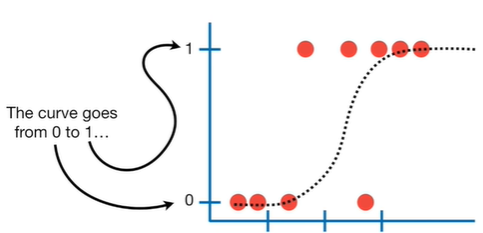

Sumber: https://youtu.be/yIYKR4sgzI8?t=222

Untuk mendapatkan kurva seperti pada gambar, berikut adalah persamaan logistic regression yang memenuhi.

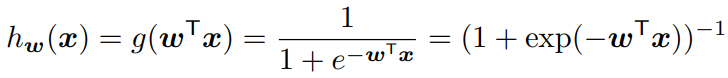

Berbeda dengan model linear, ridge, dan lasso regression yang meminimalkan fungsi loss. Pada logistic regression dilakukan proses memaksimalkan fungsi likelihood untuk menemukan parameter yang cocok dengan data.

Hal ini karena logistic regression merupakan metode klasifikasi. Sehingga, alih-alih meminimalkan perbedaan hasil prediksi, di sini memaksimalkan persamaan hasil prediksi dengan aktual.

Fungsi/persamaan likelihood dimaksimalkan melalui proses yang disebut dengan gradient ascent (tentunya bisa dipelajari sendiri dari slide :D). Berikut adalah persamaan likelihood tersebut.

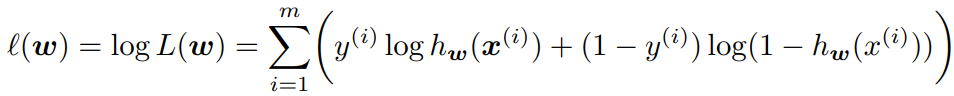

**Sumber gambar (persamaan) dan penjelasan lebih detail:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasi Logistic Regression menggunakan **sklearn** dapat dilihat pada link [berikut](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [ ]:
df_logistic = pd.read_csv('/content/spotifyreccomendation.csv').drop(columns=['title', 'first_artists', 'all_artists'])
df_logistic.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,like
0,0.486,0.881,2,-5.623,0,0.0474,0.024400,0.000000,0.429,0.6670,144.997,480707,4,1
1,0.356,0.960,4,-3.487,1,0.1040,0.014200,0.000000,0.209,0.0857,125.921,204733,4,1
2,0.487,0.949,2,-4.217,0,0.0798,0.000429,0.000029,0.231,0.4060,110.020,352427,4,1
3,0.366,0.963,11,-5.301,0,0.1420,0.000273,0.012200,0.115,0.2110,137.114,366213,4,1
4,0.412,0.920,9,-4.852,0,0.0575,0.000456,0.002600,0.110,0.4550,93.162,227440,4,1


In [ ]:
df_logistic.like.value_counts()

0    151
1    150
Name: like, dtype: int64

In [ ]:
print(df_logistic.isna().any())
print()
print(f'Length of the data: {len(df_logistic)}')
print()
df_logistic.info()

danceability        False
energy              False
key                 False
loudness            False
mode                False
speechiness         False
acousticness        False
instrumentalness    False
liveness            False
valence             False
tempo               False
duration_ms         False
time_signature      False
like                False
dtype: bool

Length of the data: 301

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      301 non-null    float64
 1   energy            301 non-null    float64
 2   key               301 non-null    int64  
 3   loudness          301 non-null    float64
 4   mode              301 non-null    int64  
 5   speechiness       301 non-null    float64
 6   acousticness      301 non-null    float64
 7   instrumentalness  301 non-null    float64
 8   liveness          

In [ ]:
X_logistic = df_logistic.drop(columns=['like'])
y_logistic = df_logistic.like

5. a) Bagi data ke dalam training dan test set dengan ukuran training sebesar 80% dari jumlah data.

#### Pembuatan Model dengan Data Asli

5. b) Buatlah suatu model logistic regression berdasarkan data asli serta tampilkan `hasil prediksi`, `confusion matrix`, dan `hasil evaluasi metriknya`. Setelah itu, lakukan **cross validation** untuk menilai performa sebenarnya dari model menggunakan data latih yang ada.

> `hasil evaluasi metriknya` mencakup:
* F1 Macro Average,
* F1 Micro Average,
* Precision Macro Average
* Precision Micro Average
* Recall Macro Average
* Recall Micro Average

> Scoring dari cross validation:
* Accuracy
* F1 Macro
* Recall Macro

#### Pembuatan Model dengan Data yang Dinormalisasi

5. c) Lakukan normalisasi terhadap data fitur yang akan digunakan.

5. d) Buatlah suatu model logistic regression berdasarkan data yang sudah di normalisasi serta tampilkan `hasil prediksi`, `confusion matrix`, dan `hasil evaluasi metriknya`. Setelah itu, lakukan **cross validation** untuk menilai performa sebenarnya dari model menggunakan data latih yang ada.

>`hasil evaluasi metriknya` mencakup:
* F1 Macro Average,
* F1 Micro Average,
* Precision Macro Average
* Precision Micro Average
* Recall Macro Average
* Recall Micro Average

> Scoring dari cross validation:
* Accuracy
* F1 Macro
* Recall Macro



5. e) Dari kedua model yang dibangun dengan data yang di normalisasi dan data yang tidak dinormalisasi, manakah yang memberikan performa terbaik? berikan analisis mengenai hal tersebut.

Jawaban:

### **Softmax Regression**

Softmax regression adalah model yang merupakan modifikasi dari logistic regression. Pada model ini, output dapat memiliki nilai lebih dari dua buah. Sehingga, softmax regression disebut sebagai multiclass classification.

Persamaan softmaxe regression:

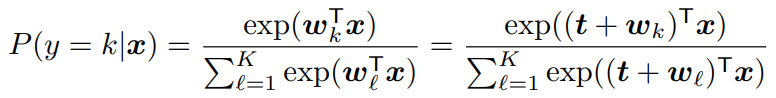

Persamaan likelihood softmaxe regression:

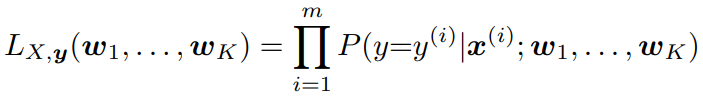

Proses memaksimalkan persamaan likelihood juga sama seperti pada logistic regression, yaitu dengan gradient ascent.

**Sumber gambar:** Slide kuliah "Linear Models for Regression and Classification" oleh Pak Adila A. Krisnadhi.

Untuk implementasi Softmax Regression menggunakan **sklearn** dapat dilihat pada link [berikut](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

Note: sama dengan link yang ada pada bagian Logistic Regression

Dataset Source: https://www.kaggle.com/datasets/supportvectorsailab/flaglike

In [ ]:
df_softmax = pd.read_csv('/content/flag.csv')
df_softmax.head()

,x1,x2,t
0,5.056366,0.939336,0.0
1,2.981938,-79.924557,0.0
2,4.665495,-96.107950,0.0
3,2.218880,26.874929,0.0
4,4.275082,-81.303200,0.0


In [ ]:
df_softmax.t.value_counts()

2.0    2459
0.0    2000
1.0    1856
Name: t, dtype: int64

In [ ]:
print(df_softmax.isna().any())
print()
print(f'Length of the data: {len(df_softmax)}')
print()
df_softmax.info()

x1    False
x2    False
t     False
dtype: bool

Length of the data: 6315

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6315 entries, 0 to 6314
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      6315 non-null   float64
 1   x2      6315 non-null   float64
 2   t       6315 non-null   float64
dtypes: float64(3)
memory usage: 148.1 KB


In [ ]:
X_softmax = df_softmax.drop(columns=['t'])
y_softmax = df_softmax.t

6. a) Bagi data ke dalam training dan test set dengan ukuran training sebesar 80% dari jumlah data.

6. b) Lakukan normalisasi pada data.

6. c) Buatlah suatu model softmax regression yang dilatih menggunakan data yang sebelumnya telah dinormalisasi serta tampilkan `hasil prediksi`, `confusion matrix`, dan `hasil evaluasi metriknya`. Setelah itu, lakukan **cross validation** untuk menilai performa sebenarnya dari model yang ada.

>`hasil evaluasi metriknya` mencakup:
* F1 Macro Average,
* F1 Micro Average,
* Precision Macro Average
* Precision Micro Average
* Recall Macro Average
* Recall Micro Average

> Scoring dari cross validation:
* Accuracy
* F1 Macro
* Recall Macro

6. d) Berikan analisis mengenai perbedaan antara regresi softmax dengan regresi logistik.

Jawaban:

# **Kaggle Competition**

Dalam rangka menerapkan pemahaman kalian pada materi Linear Model, kalian **diwajibkan** untuk mengikuti Kaggle Competition yang akan diadakan bersamaan dengan Lab 5 ini.

**Bagaimana Cara Mengikuti?**
- Join ke kompetisi di bagian bawah ini. Klik tautan tersebut untuk mengakses halaman kompetisi.
- Kerjakan solusi Anda menggunakan notebook ini. Template kode tersedia dibawah.
- Unggah hasil prediksi Anda ke dalam kompetisi Kaggle yang telah disediakan. Format dari submission telah dispesifikasikan pada bagian **Submission File** di laman Kaggle.
- Model yang boleh digunakan hanya model yang diajarkan di lab ini.
- Boleh menggunakan teknik hyperparameter tuning lainnya selain yang diajarkan di kelas/lab.
- Submission File harus sesuai dengan yang dihasilkan oleh model pada Notebook.

**Tautan Kaggle Competition**
- [Kaggle Competition - LAB 5 - Linear Model](https://www.kaggle.com/competitions/klasifikasi-lab-5-linear-model)

**Penilaian**

Untuk mendapatkan nilai penuh pada lab 5 ini, kalian **diwajibkan** untuk mengikuti kompetisi Kaggle di atas.

## EDA

## Preprocessing

## Modeling